# Sentiment Analysis of Social Media for Brand Reputation

This Google Colab project follows the required workflow:

1. Create sentiment labels  
2. Clean text data  
3. Normalize text  
4. Extract TF-IDF and BERT features  
5. Train Logistic Regression, SVM, and RoBERTa/BERT-style transformer model  
6. Evaluate using Accuracy, Precision, Recall, F1-score, and ROC-AUC  
7. Generate final sentiment prediction outcomes  
8. Compare all models  
9. Generate aspect-based sentiment outcome  

Upload `Balance dataset.csv` when prompted, or keep it in the same Colab working directory.

In [ ]:
# =========================
# CELL 1: Install libraries
# =========================
!pip -q install emoji beautifulsoup4 nltk scikit-learn pandas matplotlib seaborn sentence-transformers transformers datasets accelerate evaluate

In [ ]:
# =========================
# CELL 2: Import libraries
# =========================
import os
import re
import html
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from bs4 import BeautifulSoup
import emoji

import nltk
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
# =========================
# CELL 3: Load dataset
# =========================
# Option A: Upload manually in Colab
try:
    from google.colab import files
    uploaded = files.upload()
    if len(uploaded) > 0:
        DATA_PATH = list(uploaded.keys())[0]
    else:
        DATA_PATH = "Final dataset.csv"
except Exception:
    DATA_PATH = "Final dataset.csv"

df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
print("Columns:", list(df.columns))
display(df.head())

Saving balanced_dataset.csv to balanced_dataset (1).csv
Dataset shape: (1641, 4)
Columns: ['text', 'polarity_score', 'sentiment', 'sentiment_label']


,text,polarity_score,sentiment,sentiment_label
0,not good at all\n34 fit dure gelei connection ...,4,2,Neutral
1,Movie par mila audience ka mixed reaction kuch...,6,0,Negative
2,Service is unreliable and inconsistent.,3,2,Neutral
3,Promises for resolution never materialized.,3,2,Neutral
4,Post mein thodi hatt ke baatein thi Australia.,7,0,Negative


In [ ]:
# =========================
# CELL 4: Basic column setup
# =========================
# The uploaded dataset already has: text, polarity_score, sentiment
# This cell also supports similar datasets with slightly different column names.

possible_text_cols = ["text", "tweet", "review", "comment", "content", "message"]
text_col = None

for col in possible_text_cols:
    if col in df.columns:
        text_col = col
        break

if text_col is None:
    text_col = df.select_dtypes(include=["object"]).columns[0]

print("Text column used:", text_col)

if "sentiment" not in df.columns:
    raise ValueError("No sentiment column found. Please provide a sentiment column or create labels from polarity scores.")

df = df[[text_col, "sentiment"] + ([c for c in ["polarity_score"] if c in df.columns])].copy()
df.rename(columns={text_col: "raw_text"}, inplace=True)
display(df.head())

Text column used: text


,raw_text,sentiment,polarity_score
0,not good at all\n34 fit dure gelei connection ...,2,4
1,Movie par mila audience ka mixed reaction kuch...,0,6
2,Service is unreliable and inconsistent.,2,3
3,Promises for resolution never materialized.,2,3
4,Post mein thodi hatt ke baatein thi Australia.,0,7


Total labeled samples: 1641


,Samples,Percentage
sentiment_label,,
Negative,547,33.33
Neutral,547,33.33
Positive,547,33.33


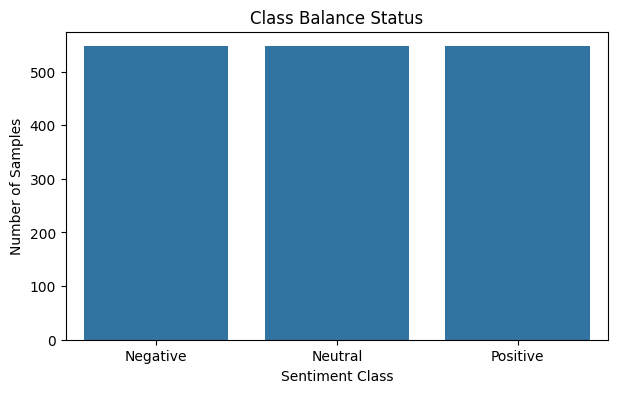

In [ ]:
# =========================
# CELL 5: Step 1 - Create sentiment labels
# =========================
# Dataset mapping based on the uploaded data:
# 1 = Positive, 0 = Neutral, 2 = Negative

def map_sentiment(value):
    if pd.isna(value):
        return np.nan

    if isinstance(value, str):
        v = value.strip().lower()
        if v in ["positive", "pos", "1"]:
            return "Positive"
        if v in ["neutral", "neu", "0"]:
            return "Neutral"
        if v in ["negative", "neg", "2", "-1"]:
            return "Negative"

    try:
        v = int(value)
        if v == 1:
            return "Positive"
        if v == 0:
            return "Neutral"
        if v == 2 or v == -1:
            return "Negative"
    except Exception:
        pass

    return np.nan

df["sentiment_label"] = df["sentiment"].apply(map_sentiment)
df = df.dropna(subset=["sentiment_label"]).copy()

label_order = ["Negative", "Neutral", "Positive"]
df["sentiment_label"] = pd.Categorical(df["sentiment_label"], categories=label_order, ordered=True)

label_counts = df["sentiment_label"].value_counts().reindex(label_order)
label_percent = (label_counts / label_counts.sum() * 100).round(2)

label_summary = pd.DataFrame({
    "Samples": label_counts,
    "Percentage": label_percent
})

print("Total labeled samples:", len(df))
display(label_summary)

plt.figure(figsize=(7, 4))
sns.barplot(x=label_summary.index, y=label_summary["Samples"])
plt.title("Class Balance Status")
plt.xlabel("Sentiment Class")
plt.ylabel("Number of Samples")
plt.show()

In [ ]:
# =========================
# CELL 7: Clean text data
# =========================
def clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text)
    text = html.unescape(text)
    text = BeautifulSoup(text, "html.parser").get_text(" ")
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"[^A-Za-z0-9#@\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

before_rows = len(df)
df["clean_text"] = df["raw_text"].apply(clean_text)

df = df.drop_duplicates(subset=["clean_text"]).copy()
df = df[df["clean_text"].str.len() > 2].copy()

after_rows = len(df)
print("Original rows:", before_rows)
print("Valid final texts after cleaning:", after_rows)
print("Removed duplicate/empty/irrelevant rows:", before_rows - after_rows)
display(df[["raw_text", "clean_text", "sentiment_label"]].head(10))

Original rows: 1641
Valid final texts after cleaning: 1285
Removed duplicate/empty/irrelevant rows: 356


,raw_text,clean_text,sentiment_label
0,not good at all\n34 fit dure gelei connection ...,not good at all 34 fit dure gelei connection l...,Negative
1,Movie par mila audience ka mixed reaction kuch...,Movie par mila audience ka mixed reaction kuch...,Neutral
2,Service is unreliable and inconsistent.,Service is unreliable and inconsistent,Negative
3,Promises for resolution never materialized.,Promises for resolution never materialized,Negative
4,Post mein thodi hatt ke baatein thi Australia.,Post mein thodi hatt ke baatein thi Australia,Neutral
5,Kharab packaging ke kaaran product damage ho g...,Kharab packaging ke kaaran product damage ho gaya,Negative
6,mota moti vlo price hisebe,mota moti vlo price hisebe,Neutral
7,Product thoda mehenga laga.,Product thoda mehenga laga,Neutral
8,akta nostomood tai nosto hoia gese,akta nostomood tai nosto hoia gese,Neutral
9,Deal ke cancellation policy clear thi process ...,Deal ke cancellation policy clear thi process ...,Positive


In [ ]:
# =========================
# CELL 8: Step 3 - Normalize text
# =========================
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def normalize_text(text):
    text = str(text).lower()
    text = emoji.demojize(text, delimiters=(" ", " "))
    text = re.sub(r"@\w+", " mention ", text)
    text = re.sub(r"#(\w+)", r"\1", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

df["processed_text"] = df["clean_text"].apply(normalize_text)
df = df[df["processed_text"].str.len() > 0].copy()

print("Final valid texts after normalization:", len(df))
print("\nDemonstration of preprocessing quality:")
display(df[["raw_text", "clean_text", "processed_text", "sentiment_label"]].sample(min(10, len(df)), random_state=RANDOM_STATE))

Final valid texts after normalization: 1285

Demonstration of preprocessing quality:


,raw_text,clean_text,processed_text,sentiment_label
1574,Customer complaints generally do not receive p...,Customer complaints generally do not receive p...,customer complaint generally receive proper at...,Neutral
851,Post ki content style bohot pasand aayi inform...,Post ki content style bohot pasand aayi inform...,post ki content style bohot pasand aayi inform...,Positive
714,Show mein suspense ki kami thi Pakistan.,Show mein suspense ki kami thi Pakistan,show mein suspense ki kami thi pakistan,Negative
1092,alhamdulillah valo ekta products sobai nite paren,alhamdulillah valo ekta products sobai nite paren,alhamdulillah valo ekta product sobai nite paren,Neutral
1517,Maine purchase se khush hu.,Maine purchase se khush hu,maine purchase se khush hu,Positive
1507,Mujhe pasand nahi aaya.,Mujhe pasand nahi aaya,mujhe pasand nahi aaya,Negative
263,Delivery perfectly hui Bangladesh.,Delivery perfectly hui Bangladesh,delivery perfectly hui bangladesh,Positive
670,onek sundor ekai products sobai nite paren del...,onek sundor ekai products sobai nite paren del...,onek sundor ekai product sobai nite paren deli...,Neutral
321,The user interface is not intuitive anymore.,The user interface is not intuitive anymore,user interface intuitive anymore,Negative
465,Deal ki delivery fast thi Pakistan.,Deal ki delivery fast thi Pakistan,deal ki delivery fast thi pakistan,Positive


In [ ]:
# =========================
# CELL 8: Prepare train-test split
# =========================
label_to_id = {"Negative": 0, "Neutral": 1, "Positive": 2}
id_to_label = {v: k for k, v in label_to_id.items()}

df["label_id"] = df["sentiment_label"].astype(str).map(label_to_id)

X_train, X_test, y_train, y_test = train_test_split(
    df["processed_text"],
    df["label_id"],
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df["label_id"]
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Labels:", id_to_label)

Training samples: 1028
Testing samples: 257
Labels: {0: 'Negative', 1: 'Neutral', 2: 'Positive'}


In [ ]:
# =========================
# CELL 9: Evaluation helper function
# =========================
results = []

def evaluate_model(model_name, y_true, y_pred, y_score=None):
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    roc_auc = np.nan
    if y_score is not None:
        try:
            y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
            roc_auc = roc_auc_score(y_true_bin, y_score, average="weighted", multi_class="ovr")
        except Exception:
            roc_auc = np.nan

    row = {
        "Model": model_name,
        "Accuracy": round(accuracy, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1-score": round(f1, 4),
        "ROC-AUC": round(float(roc_auc), 4) if not pd.isna(roc_auc) else np.nan
    }
    results.append(row)

    print("\nModel:", model_name)
    print("Accuracy:", row["Accuracy"])
    print("Precision:", row["Precision"])
    print("Recall:", row["Recall"])
    print("F1-score:", row["F1-score"])
    print("ROC-AUC:", row["ROC-AUC"])
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, target_names=["Negative", "Neutral", "Positive"], zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=["Negative", "Neutral", "Positive"], yticklabels=["Negative", "Neutral", "Positive"])
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return row


Model: TF-IDF + Logistic Regression
Accuracy: 0.8444
Precision: 0.8474
Recall: 0.8444
F1-score: 0.8442
ROC-AUC: 0.9298

Classification report:
              precision    recall  f1-score   support

    Negative       0.89      0.78      0.83        80
     Neutral       0.79      0.86      0.83        88
    Positive       0.87      0.89      0.88        89

    accuracy                           0.84       257
   macro avg       0.85      0.84      0.84       257
weighted avg       0.85      0.84      0.84       257



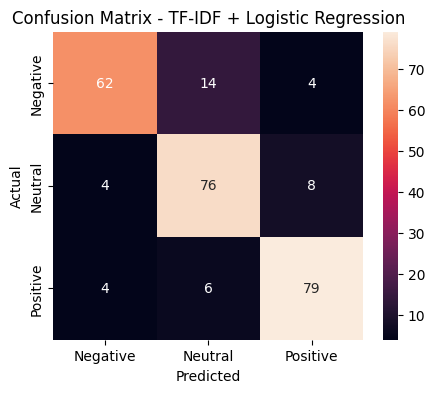

{'Model': 'TF-IDF + Logistic Regression',
 'Accuracy': 0.8444,
 'Precision': 0.8474,
 'Recall': 0.8444,
 'F1-score': 0.8442,
 'ROC-AUC': 0.9298}

In [ ]:
# =========================
# CELL 10: Step 4 + Step 5 - TF-IDF + Logistic Regression
# =========================
tfidf_logreg_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))
])

tfidf_logreg_model.fit(X_train, y_train)
pred_logreg = tfidf_logreg_model.predict(X_test)
score_logreg = tfidf_logreg_model.predict_proba(X_test)

evaluate_model("TF-IDF + Logistic Regression", y_test, pred_logreg, score_logreg)


Model: TF-IDF + SVM
Accuracy: 0.8366
Precision: 0.8392
Recall: 0.8366
F1-score: 0.8363
ROC-AUC: 0.9416

Classification report:
              precision    recall  f1-score   support

    Negative       0.89      0.78      0.83        80
     Neutral       0.78      0.83      0.81        88
    Positive       0.85      0.90      0.87        89

    accuracy                           0.84       257
   macro avg       0.84      0.83      0.84       257
weighted avg       0.84      0.84      0.84       257



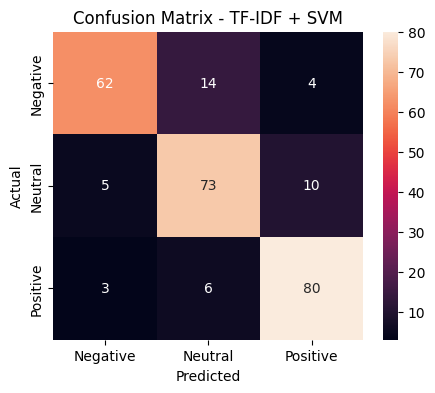

{'Model': 'TF-IDF + SVM',
 'Accuracy': 0.8366,
 'Precision': 0.8392,
 'Recall': 0.8366,
 'F1-score': 0.8363,
 'ROC-AUC': 0.9416}

In [ ]:
# =========================
# CELL 11: Step 4 + Step 5 - TF-IDF + SVM
# =========================
svm_base = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
    ("clf", CalibratedClassifierCV(
        LinearSVC(class_weight="balanced", random_state=RANDOM_STATE),
        cv=3
    ))
])

svm_base.fit(X_train, y_train)
pred_svm = svm_base.predict(X_test)
score_svm = svm_base.predict_proba(X_test)

evaluate_model("TF-IDF + SVM", y_test, pred_svm, score_svm)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/33 [00:00<?, ?it/s]

Batches:   0%|          | 0/9 [00:00<?, ?it/s]


Model: BERT Embeddings + Logistic Regression
Accuracy: 0.8132
Precision: 0.8149
Recall: 0.8132
F1-score: 0.8128
ROC-AUC: 0.9054

Classification report:
              precision    recall  f1-score   support

    Negative       0.85      0.75      0.79        80
     Neutral       0.79      0.84      0.81        88
    Positive       0.82      0.84      0.83        89

    accuracy                           0.81       257
   macro avg       0.82      0.81      0.81       257
weighted avg       0.81      0.81      0.81       257



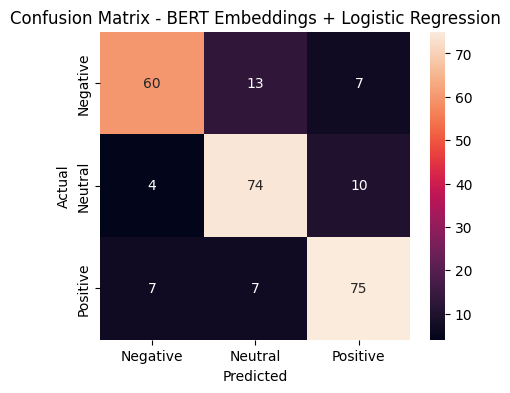

{'Model': 'BERT Embeddings + Logistic Regression',
 'Accuracy': 0.8132,
 'Precision': 0.8149,
 'Recall': 0.8132,
 'F1-score': 0.8128,
 'ROC-AUC': 0.9054}

In [ ]:
# =========================
# CELL 12: Step 4 + Step 5 - BERT embeddings + Logistic Regression
# =========================
# This is the advanced representation part.
# Sentence-BERT converts every text into dense contextual embeddings.

from sentence_transformers import SentenceTransformer

embedding_model_name = "sentence-transformers/all-MiniLM-L6-v2"
embedding_model = SentenceTransformer(embedding_model_name)

X_train_emb = embedding_model.encode(
    X_train.tolist(),
    show_progress_bar=True,
    convert_to_numpy=True,
    batch_size=32
)

X_test_emb = embedding_model.encode(
    X_test.tolist(),
    show_progress_bar=True,
    convert_to_numpy=True,
    batch_size=32
)

bert_logreg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
bert_logreg.fit(X_train_emb, y_train)

pred_bert_emb = bert_logreg.predict(X_test_emb)
score_bert_emb = bert_logreg.predict_proba(X_test_emb)

evaluate_model("BERT Embeddings + Logistic Regression", y_test, pred_bert_emb, score_bert_emb)

Map:   0%|          | 0/1028 [00:00<?, ? examples/s]

Map:   0%|          | 0/257 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.933233,0.634956,0.762646,0.776837,0.762646,0.757864
2,0.628470,0.587816,0.793774,0.797632,0.793774,0.790589


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


Model: Fine-tuned RoBERTa
Accuracy: 0.7938
Precision: 0.7976
Recall: 0.7938
F1-score: 0.7906
ROC-AUC: 0.9006

Classification report:
              precision    recall  f1-score   support

    Negative       0.84      0.65      0.73        80
     Neutral       0.76      0.82      0.79        88
    Positive       0.80      0.90      0.85        89

    accuracy                           0.79       257
   macro avg       0.80      0.79      0.79       257
weighted avg       0.80      0.79      0.79       257



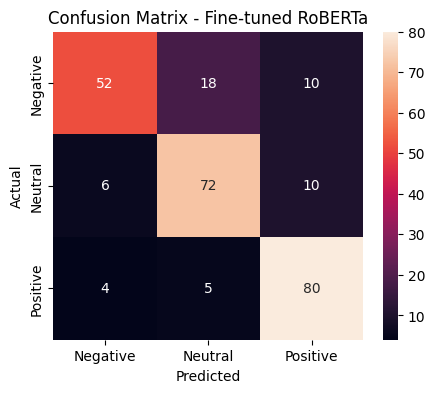

In [ ]:
# =========================
# CELL 13: Step 5 - RoBERTa/BERT transformer fine-tuning
# =========================
# This cell trains an actual transformer classifier.
# For faster execution, it uses distilroberta-base.
# Set RUN_TRANSFORMER_TRAINING = False if your Colab runtime is too slow.

RUN_TRANSFORMER_TRAINING = True

if RUN_TRANSFORMER_TRAINING:
    import torch
    from datasets import Dataset
    from transformers import (
        AutoTokenizer,
        AutoModelForSequenceClassification,
        TrainingArguments,
        Trainer,
        DataCollatorWithPadding
    )

    transformer_model_name = "distilroberta-base"

    train_df = pd.DataFrame({"text": X_train.tolist(), "label": y_train.tolist()})
    test_df = pd.DataFrame({"text": X_test.tolist(), "label": y_test.tolist()})

    train_dataset = Dataset.from_pandas(train_df)
    test_dataset = Dataset.from_pandas(test_df)

    tokenizer = AutoTokenizer.from_pretrained(transformer_model_name)

    def tokenize_batch(batch):
        return tokenizer(batch["text"], truncation=True, max_length=128)

    train_dataset = train_dataset.map(tokenize_batch, batched=True)
    test_dataset = test_dataset.map(tokenize_batch, batched=True)

    model = AutoModelForSequenceClassification.from_pretrained(
        transformer_model_name,
        num_labels=3,
        id2label=id_to_label,
        label2id=label_to_id
    )

    training_args = TrainingArguments(
        output_dir="./roberta_brand_sentiment_model",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=2,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        logging_steps=50,
        report_to="none"
    )

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        precision, recall, f1, _ = precision_recall_fscore_support(
            labels, preds, average="weighted", zero_division=0
        )
        acc = accuracy_score(labels, preds)
        return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        data_collator=data_collator,
        compute_metrics=compute_metrics
    )

    trainer.train()

    roberta_outputs = trainer.predict(test_dataset)
    roberta_logits = roberta_outputs.predictions
    roberta_probs = torch.softmax(torch.tensor(roberta_logits), dim=1).numpy()
    pred_roberta = np.argmax(roberta_probs, axis=1)

    evaluate_model("Fine-tuned RoBERTa", y_test, pred_roberta, roberta_probs)
else:
    print("Transformer fine-tuning skipped.")

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,TF-IDF + Logistic Regression,0.8444,0.8474,0.8444,0.8442,0.9298
1,TF-IDF + SVM,0.8366,0.8392,0.8366,0.8363,0.9416
2,BERT Embeddings + Logistic Regression,0.8132,0.8149,0.8132,0.8128,0.9054
3,Fine-tuned RoBERTa,0.7938,0.7976,0.7938,0.7906,0.9006


Best-performing model: TF-IDF + Logistic Regression


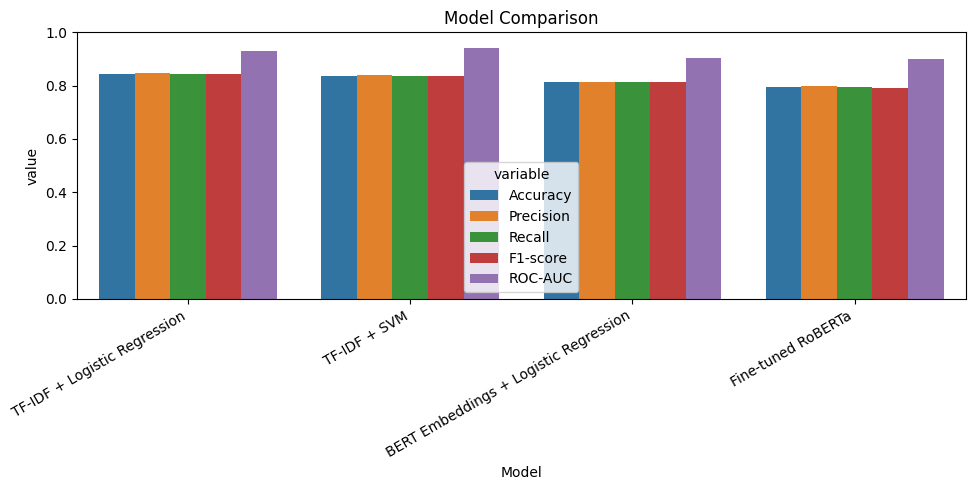

In [ ]:
# =========================
# CELL 14: Step 6 + Step 8 - Model comparison outcome
# =========================
comparison_df = pd.DataFrame(results).sort_values(by="F1-score", ascending=False).reset_index(drop=True)
display(comparison_df)

best_model_name = comparison_df.iloc[0]["Model"]
print("Best-performing model:", best_model_name)

plt.figure(figsize=(10, 5))
plot_df = comparison_df.melt(id_vars="Model", value_vars=["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"])
sns.barplot(data=plot_df, x="Model", y="value", hue="variable")
plt.title("Model Comparison")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [ ]:
# =========================
# CELL 15: Step 7 - Generate sentiment predictions for all brand-related texts
# =========================
# For final output, automatically use the best available model.
# If RoBERTa is best and was trained, it is used. Otherwise the best classical/embedding model is used.

def predict_with_best_model(texts):
    processed = [normalize_text(clean_text(t)) for t in texts]

    if best_model_name == "Fine-tuned RoBERTa" and "trainer" in globals():
        pred_data = Dataset.from_pandas(pd.DataFrame({"text": processed}))
        pred_data = pred_data.map(tokenize_batch, batched=True)
        output = trainer.predict(pred_data)
        probs = torch.softmax(torch.tensor(output.predictions), dim=1).numpy()
        preds = probs.argmax(axis=1)
        return preds, probs

    if best_model_name == "BERT Embeddings + Logistic Regression":
        emb = embedding_model.encode(processed, show_progress_bar=True, convert_to_numpy=True, batch_size=32)
        preds = bert_logreg.predict(emb)
        probs = bert_logreg.predict_proba(emb)
        return preds, probs

    if best_model_name == "TF-IDF + SVM":
        preds = svm_base.predict(processed)
        probs = svm_base.predict_proba(processed)
        return preds, probs

    preds = tfidf_logreg_model.predict(processed)
    probs = tfidf_logreg_model.predict_proba(processed)
    return preds, probs

all_preds, all_probs = predict_with_best_model(df["raw_text"].tolist())

df["predicted_sentiment"] = [id_to_label[int(p)] for p in all_preds]
df["negative_probability"] = all_probs[:, 0]
df["neutral_probability"] = all_probs[:, 1]
df["positive_probability"] = all_probs[:, 2]

final_predictions = df[[
    "raw_text",
    "clean_text",
    "processed_text",
    "sentiment_label",
    "predicted_sentiment",
    "negative_probability",
    "neutral_probability",
    "positive_probability"
]].copy()

display(final_predictions.head(20))

final_predictions.to_csv("final_sentiment_predictions.csv", index=False)
comparison_df.to_csv("model_comparison_results.csv", index=False)

print("Saved: final_sentiment_predictions.csv")
print("Saved: model_comparison_results.csv")

,raw_text,clean_text,processed_text,sentiment_label,predicted_sentiment,negative_probability,neutral_probability,positive_probability
0,not good at all\n34 fit dure gelei connection ...,not good at all 34 fit dure gelei connection l...,good fit dure gelei connection lost hoiya jai,Negative,Negative,0.544524,0.236619,0.218857
1,Movie par mila audience ka mixed reaction kuch...,Movie par mila audience ka mixed reaction kuch...,movie par mila audience ka mixed reaction kuch...,Neutral,Positive,0.338684,0.150231,0.511085
2,Service is unreliable and inconsistent.,Service is unreliable and inconsistent,service unreliable inconsistent,Negative,Negative,0.712598,0.148448,0.138955
3,Promises for resolution never materialized.,Promises for resolution never materialized,promise resolution never materialized,Negative,Negative,0.663384,0.182966,0.153649
4,Post mein thodi hatt ke baatein thi Australia.,Post mein thodi hatt ke baatein thi Australia,post mein thodi hatt ke baatein thi australia,Neutral,Neutral,0.208973,0.429503,0.361523
5,Kharab packaging ke kaaran product damage ho g...,Kharab packaging ke kaaran product damage ho gaya,kharab packaging ke kaaran product damage ho gaya,Negative,Negative,0.672813,0.159425,0.167762
6,mota moti vlo price hisebe,mota moti vlo price hisebe,mota moti vlo price hisebe,Neutral,Neutral,0.216259,0.626219,0.157522
7,Product thoda mehenga laga.,Product thoda mehenga laga,product thoda mehenga laga,Neutral,Neutral,0.163169,0.696612,0.140219
8,akta nostomood tai nosto hoia gese,akta nostomood tai nosto hoia gese,akta nostomood tai nosto hoia gese,Neutral,Neutral,0.242593,0.546846,0.210561
9,Deal ke cancellation policy clear thi process ...,Deal ke cancellation policy clear thi process ...,deal ke cancellation policy clear thi process ...,Positive,Positive,0.171987,0.085644,0.742369


Saved: final_sentiment_predictions.csv
Saved: model_comparison_results.csv


,aspect,predicted_sentiment,count
0,delivery,Negative,24
1,delivery,Neutral,67
2,delivery,Positive,48
3,price,Negative,7
4,price,Neutral,49
5,price,Positive,22
6,product quality,Negative,103
7,product quality,Neutral,174
8,product quality,Positive,100
9,service,Negative,135


predicted_sentiment,Negative,Neutral,Positive,Total,Dominant Sentiment
aspect,,,,,
delivery,24.0,67.0,48.0,139.0,Neutral
price,7.0,49.0,22.0,78.0,Neutral
product quality,103.0,174.0,100.0,377.0,Neutral
service,135.0,15.0,41.0,191.0,Negative
trust,3.0,2.0,9.0,14.0,Positive


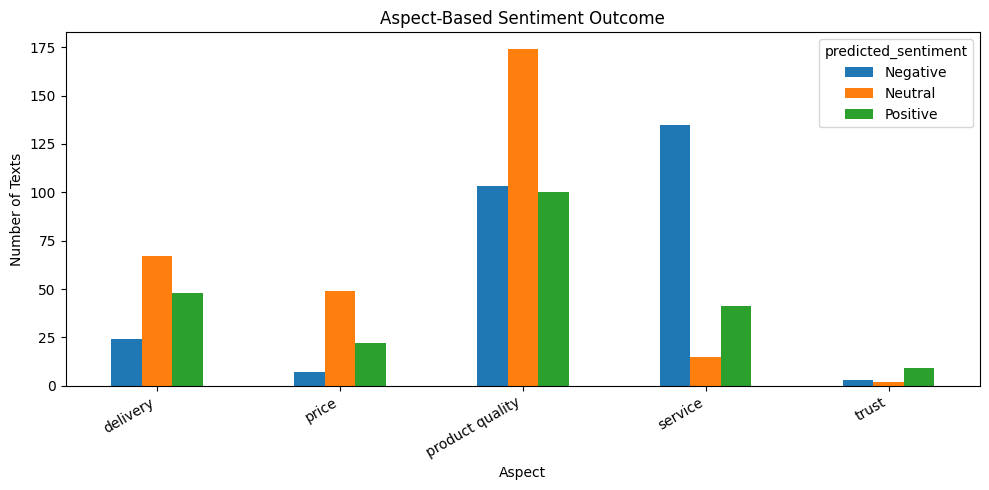

Saved: aspect_level_sentiment_rows.csv
Saved: aspect_based_sentiment_summary.csv


In [ ]:
# =========================
# CELL 16: Step 9 - Aspect-based sentiment outcome
# =========================
aspect_keywords = {
    "product quality": [
        "quality", "product", "works", "working", "performance", "durable", "broken", "defective",
        "amazing", "bad", "good", "excellent", "poor"
    ],
    "price": [
        "price", "cost", "cheap", "expensive", "value", "worth", "money", "budget", "affordable"
    ],
    "service": [
        "service", "support", "customer", "staff", "help", "response", "care", "communication"
    ],
    "delivery": [
        "delivery", "delayed", "shipping", "ship", "arrived", "late", "fast", "slow", "courier"
    ],
    "trust": [
        "trust", "reliable", "fake", "authentic", "brand", "reputation", "scam", "genuine", "safe"
    ]
}

def detect_aspects(text):
    text_lower = str(text).lower()
    matched = []
    for aspect, keywords in aspect_keywords.items():
        if any(re.search(r"\b" + re.escape(k) + r"\b", text_lower) for k in keywords):
            matched.append(aspect)
    return matched

aspect_rows = []
for _, row in final_predictions.iterrows():
    aspects = detect_aspects(row["raw_text"] + " " + row["processed_text"])
    for aspect in aspects:
        aspect_rows.append({
            "aspect": aspect,
            "predicted_sentiment": row["predicted_sentiment"],
            "text": row["raw_text"]
        })

aspect_df = pd.DataFrame(aspect_rows)

if len(aspect_df) == 0:
    print("No aspects found using the keyword dictionary. Add more keywords for your dataset.")
else:
    aspect_summary = (
        aspect_df.groupby(["aspect", "predicted_sentiment"])
        .size()
        .reset_index(name="count")
        .sort_values(["aspect", "predicted_sentiment"])
    )

    display(aspect_summary)

    aspect_pivot = aspect_summary.pivot_table(
        index="aspect",
        columns="predicted_sentiment",
        values="count",
        fill_value=0
    )

    for col in ["Negative", "Neutral", "Positive"]:
        if col not in aspect_pivot.columns:
            aspect_pivot[col] = 0

    aspect_pivot = aspect_pivot[["Negative", "Neutral", "Positive"]]
    aspect_pivot["Total"] = aspect_pivot.sum(axis=1)
    aspect_pivot["Dominant Sentiment"] = aspect_pivot[["Negative", "Neutral", "Positive"]].idxmax(axis=1)

    display(aspect_pivot)

    aspect_pivot[["Negative", "Neutral", "Positive"]].plot(kind="bar", figsize=(10, 5))
    plt.title("Aspect-Based Sentiment Outcome")
    plt.xlabel("Aspect")
    plt.ylabel("Number of Texts")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

    aspect_df.to_csv("aspect_level_sentiment_rows.csv", index=False)
    aspect_pivot.to_csv("aspect_based_sentiment_summary.csv")
    print("Saved: aspect_level_sentiment_rows.csv")
    print("Saved: aspect_based_sentiment_summary.csv")

,Predicted Samples,Percentage
predicted_sentiment,,
Negative,400,31.13
Neutral,451,35.10
Positive,434,33.77


Overall brand reputation appears positive.


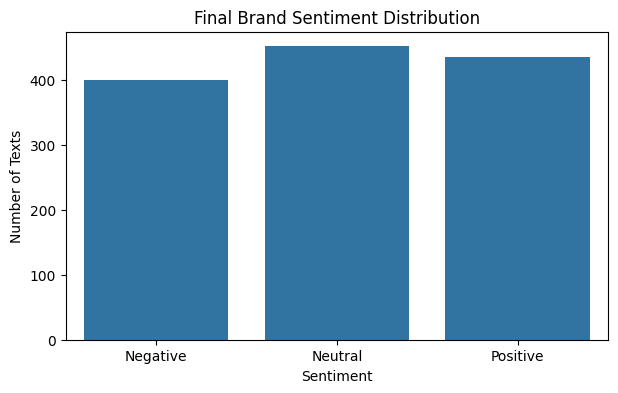

In [ ]:
# =========================
# CELL 17: Brand reputation summary
# =========================
sentiment_distribution = final_predictions["predicted_sentiment"].value_counts().reindex(["Negative", "Neutral", "Positive"]).fillna(0).astype(int)
sentiment_percentage = (sentiment_distribution / sentiment_distribution.sum() * 100).round(2)

reputation_summary = pd.DataFrame({
    "Predicted Samples": sentiment_distribution,
    "Percentage": sentiment_percentage
})

display(reputation_summary)

positive_rate = sentiment_percentage.get("Positive", 0)
negative_rate = sentiment_percentage.get("Negative", 0)

if positive_rate > negative_rate:
    reputation_status = "Overall brand reputation appears positive."
elif negative_rate > positive_rate:
    reputation_status = "Overall brand reputation needs attention because negative sentiment is higher."
else:
    reputation_status = "Overall brand reputation is balanced or mixed."

print(reputation_status)

plt.figure(figsize=(7, 4))
sns.barplot(x=reputation_summary.index, y=reputation_summary["Predicted Samples"])
plt.title("Final Brand Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Texts")
plt.show()

In [ ]:
# =========================
# CELL 18: Download output files from Colab
# =========================
# Run this cell in Google Colab after all previous cells finish.

try:
    from google.colab import files

    output_files = [
        "final_sentiment_predictions.csv",
        "model_comparison_results.csv",
        "aspect_level_sentiment_rows.csv",
        "aspect_based_sentiment_summary.csv"
    ]

    for file in output_files:
        if os.path.exists(file):
            files.download(file)
except Exception:
    print("Download works only in Google Colab. Files are already saved in the working directory.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>